In [1]:
import os

# Change the current working directory to the path within Google Drive
os.chdir('/content/drive/MyDrive/Level_6_AI_')

# Verify the new current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Level_6_AI_


In [2]:
import numpy as np

def mcp_neurons(X1, X2, T):
    sums = np.array(X1) + np.array(X2)
    return (sums >= T).astype(int)


x_1 = [0,1,0,2]
x_2 = [0,0,0,0]

# And Gate
print(mcp_neurons(x_1,x_2, 2))


# Or Gate
print(mcp_neurons(x_1,x_2, 1))



[0 0 0 1]
[0 1 0 1]


---


# Limitations of MCP
- MCP Neurons can only capture linear relationships. As such XOR Can't be solved by using **just one MCP Neuron**
    - Note that it is possible with 2 MCP Neurons
    - ![MCP XOR](https://i.imgur.com/yWI2piD.png)

- The weights are Fixed / hand-crafted, so can't learn
- Output must be binary
- Threshold T is hardcoded and to be setmanually


# Can MCP Neurons Model XOR

- Not with just 1, XOR is not linearly seperable

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("assets/mnist_0_1.csv")
data


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12660,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12661,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12662,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data = np.array(data)
X = data[:,1:]
Y = data[:, 0]

In [5]:
# Decision Function

def decide(x, w, b):
    preds = x @ w + b
    y_preds = (preds >= 0).astype(int)

    return y_preds


In [6]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    accuracy_history = []
    for epoch in range(epochs):
        print(epoch, sep=', ')
        correct = 0
        for j in range(len(X)):
            y_pred = 1 if (np.dot(X[j], weights) + bias) >= 0 else 0
            error = y[j] - y_pred
            weights = weights + learning_rate * error * X[j]
            bias = bias + learning_rate * error
            if error == 0:
                correct += 1
        accuracy = correct / len(X)
        accuracy_history.append(accuracy)
    return weights, bias, accuracy_history


weights = np.zeros(X.shape[1])  # 784 zeros
bias = 0

weights, bias, accuracy_history = train_perceptron(X, Y, weights, bias)
print(f"Final Accuracy: {accuracy_history[-1]:.4f}")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Final Accuracy: 1.0000


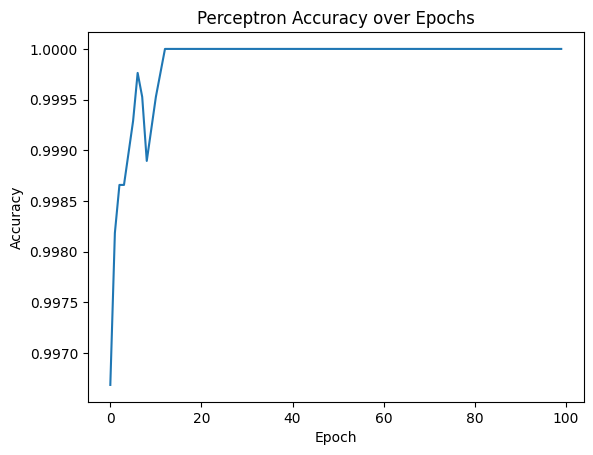

In [7]:
import matplotlib.pyplot as plt
plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy over Epochs")
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Final Accuracy: 0.9858


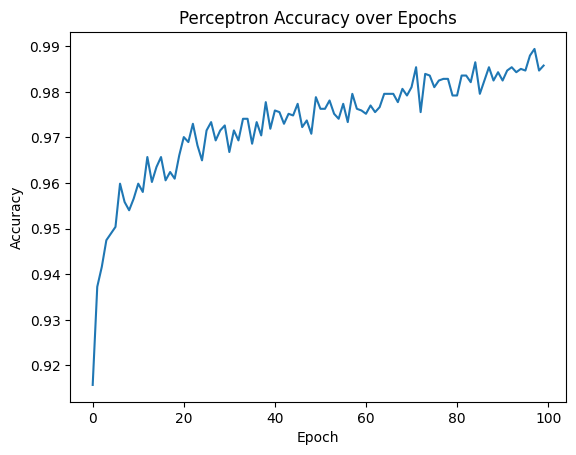

In [8]:
# load new dataset
df_3_5 = pd.read_csv("assets/mnist_3_5.csv")
X = df_3_5.drop(columns=["label"]).values
y = (df_3_5["label"].values == 5).astype(int)  # remap 3→0, 5→1

# reset weights
weights = np.zeros(X.shape[1])
bias = 0

# train
weights, bias, accuracy_history = train_perceptron(X, y, weights, bias)
print(f"Final Accuracy: {accuracy_history[-1]:.4f}")

import matplotlib.pyplot as plt
plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy over Epochs")
plt.show()

# Q1: What does the shape of X represent?
X is `(n_samples, 784)`

 each row is one image, each column is one pixel. 784 = 28×28 flattened.

# Q2: What does the shape of y represent?
y is `(n_samples,)` ; one label per image, either 0 or 1.

# Q3: What does the weights array represent?
784 weights, one per pixel. Each weight represents how much that pixel contributes to the final classification decision.

# Q4: Why initialize weights to zero?
It's a neutral starting point ; no bias toward either class. For a simple perceptron it works fine since the update rule will push weights in the right direction from the first mistake.

# Q5: What is the purpose of `np.dot(X[i], weights) + bias`?
It computes the weighted sum z for a single sample ; the aggregated input before the step function decides the output.

# Q6: What happens when prediction is wrong?
Weights and bias get nudged using `w = w + learning_rate(y - y_pred)x` and `b = b + learning_rate(y - y_pred)`. If we predicted too high, they decrease. Too low, they increase.

# Q7: Why is final accuracy important?
It tells you if the perceptron actually converged and learned a useful decision boundary. For 0 vs 1 you'd expect near 100% since they're linearly separable.

# Q8: What does misclassified_idx store?
Indices of samples where `y_pred != y_true`. Used to pull those specific images out of X for visualisation.

# Q9: How do you interpret "All images were correctly classified"?
The perceptron converged ; it found a linear decision boundary that perfectly separates 0s from 1s in this dataset.

## Conclusion ; 3 vs 5 Classification

The perceptron achieves lower accuracy on 3 vs 5 compared to 0 vs 1.
This is expected ; 3 and 5 share similar visual structure (curved strokes, similar height),
making them harder to separate with a single linear boundary.

